In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

transactions = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings.csv"
)

scorecard = pd.read_csv(
    "../reports/fund_scorecard.csv"
)

fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

In [3]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [4]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = nav.groupby(
    "amfi_code"
)["nav"].pct_change()

In [5]:
risk_list = []

for code, group in nav.groupby("amfi_code"):

    returns = group[
        "daily_return"
    ].dropna()

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    risk_list.append([
        code,
        var_95,
        cvar_95
    ])

var_cvar_df = pd.DataFrame(
    risk_list,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.064206,-0.105590
1,100025,-0.020707,-0.042778
2,100033,-0.069870,-0.174555
3,101206,-0.074686,-0.151855
4,101207,-0.089537,-0.161950


In [6]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

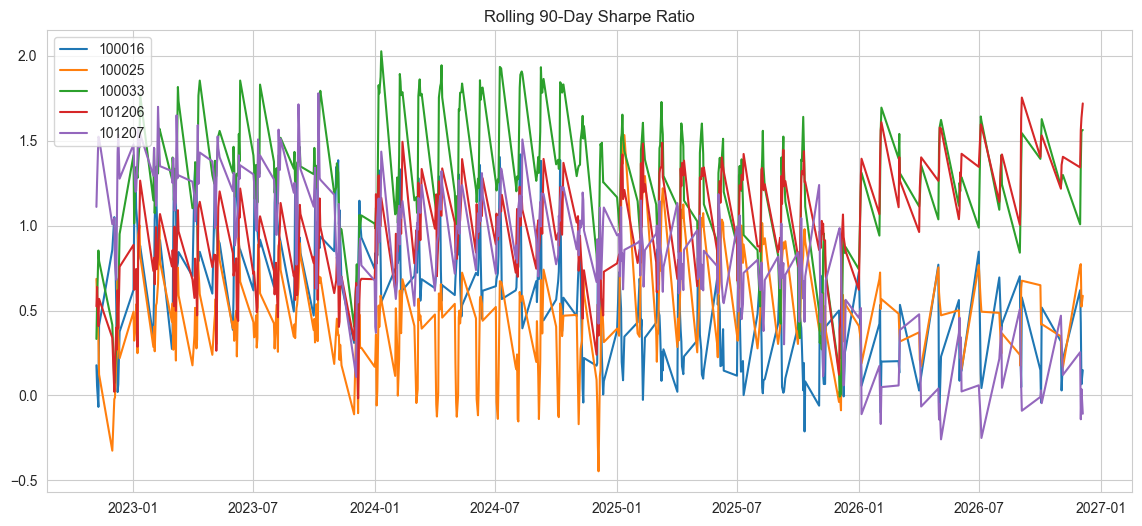

In [7]:
top5 = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(14,6))

for code in top5:

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    rolling_sharpe = (
        fund["daily_return"]
        .rolling(90)
        .mean()
        /
        fund["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        fund["date"],
        rolling_sharpe,
        label=code
    )

plt.legend()

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [8]:
transactions["year"] = transactions[
    "transaction_date"
].dt.year

first_year = transactions.groupby(
    "investor_id"
)["year"].min()

transactions["cohort_year"] = transactions[
    "investor_id"
].map(first_year)

cohort = transactions.groupby(
    "cohort_year"
).agg({
    "amount_inr":"mean",
    "investor_id":"count"
})

cohort.head()

,amount_inr,investor_id
cohort_year,,
2024,107422.541832,32499
2025,109158.577061,279


In [9]:
sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
]

sip_txn = sip_txn.sort_values(
    ["investor_id","transaction_date"]
)

sip_txn["gap_days"] = sip_txn.groupby(
    "investor_id"
)["transaction_date"].diff().dt.days

at_risk = sip_txn[
    sip_txn["gap_days"] > 35
]

at_risk.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,year,cohort_year,gap_days
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2025,2024,76.0
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2025,2024,238.0
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2025,2024,238.0
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,2024,59.0


In [10]:
holdings["weight_sq"] = (
    holdings["weight_pct"] / 100
) ** 2

hhi = holdings.groupby(
    "amfi_code"
)["weight_sq"].sum()

hhi_df = hhi.reset_index()

hhi_df.columns = [
    "amfi_code",
    "HHI"
]

hhi_df.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709
